# SparK: A Visualization Demo
A demo using our pre-trained SparK model (ConvNeXt-L with input size 384, or ConvNeXt-S with 224) to reconstruct masked images.
The mask is whether specified by the user or randomly generated.

## 1. Preparation
Install dependencies, specify the device, and specify the pre-trained model.

In [1]:
# install dependencies
import sys
if 'google.colab' in sys.modules:
    !pip3 install -r requirements.txt

# specify the device to use
USING_GPU_IF_AVAILABLE = True
# specify the CNN to use
USING_LARGE384_MODEL = True    # True for ConvNeXt-L-384, False for ConvNeXt-S-224
import torch
_ = torch.empty(1)
if torch.cuda.is_available() and USING_GPU_IF_AVAILABLE:
    _ = _.cuda()
DEVICE = _.device
print(f'[DEVICE={DEVICE}]')


/home/castrechini/projects/SSL-MedicalImagining-CL-MAE/.venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[DEVICE=cuda:0]


## 2. Define utils: load data

In [2]:
from PIL import Image
import torchvision.transforms as T
# IMAGENET_DEFAULT_MEAN = (0.485, 0.456, 0.406)
# IMAGENET_DEFAULT_STD = (0.229, 0.224, 0.225)
def load_image(img_file):
    transform = T.Compose([
        # T.Resize((576, 1120)),
        T.ToTensor(),
    ])
    image = Image.open(img_file).convert("RGB")
    return transform(image).unsqueeze(0)  # Add batch dimension

## 3. Define utils: build a SparK model

In [3]:
import os
from decoder import LightDecoder
from encoder import SparseEncoder
from models import build_sparse_encoder
from spark import SparK
def build_spark():
    # # download and load the checkpoint
    # if USING_LARGE384_MODEL:
    #     model_name, input_size = 'convnext_large', 384
    #     ckpt_file = 'cnxL384_withdecoder_1kpretrained_spark_style.pth'
    #     ckpt_link = 'https://drive.google.com/file/d/1ZI9Jgtb3fKWE_vDFEly29w-1FWZSNwa0/view?usp=share_link'
    # else:
    #     model_name, input_size = 'convnext_small', 224
    #     ckpt_file = 'cnxS224_withdecoder_1kpretrained_spark_style.pth'
    #     ckpt_link = 'https://drive.google.com/file/d/1bKvrE4sNq1PfzhWlQJXEPrl2kHqHRZM-/view?usp=share_link'
    # assert os.path.exists(ckpt_file), f'please download checkpoint {ckpt_file} from {ckpt_link}'
    model_name, input_size = 'convnext_small', 224
    ckpt_file = '/home/castrechini/projects/SSL-MedicalImagining-CL-MAE/results/convnextsmall_4/convnext_small_still_pretraining.pth'
    pretrained_state = torch.load(ckpt_file, map_location='cpu')
    
    # build a SparK model
    enc: SparseEncoder = build_sparse_encoder(model_name,  input_width=576, input_height=1120)
    spark = SparK(
        sparse_encoder=enc, dense_decoder=LightDecoder(enc.downsample_ratio, sbn=False),
        mask_ratio=0.6, densify_norm='ln', sbn=False,
    ).to(DEVICE)
    spark.eval(), [p.requires_grad_(False) for p in spark.parameters()]
    
    # load the checkpoint
    # missing, unexpected = spark.load_state_dict(pretrained_state, strict=False)
    missing, unexpected = spark.load_state_dict(pretrained_state.get('module', pretrained_state), strict=False)

    assert len(missing) == 0, f'load_state_dict missing keys: {missing}'
    assert len(unexpected) == 0, f'load_state_dict unexpected keys: {unexpected}'
    del pretrained_state
    return spark


## 4. Define utils: visualize

In [17]:
import matplotlib.pyplot as plt
def show(spark: SparK, img_file='path_to_your_image.jpg', active_b1ff: torch.BoolTensor = None):
    # Load and preprocess the image
    inp_bchw = load_image(img_file).to(DEVICE)
    
    # Perform forward pass and get reconstructed images
    spark.eval()
    with torch.no_grad():
        inp_bchw, masked_bchw, rec_or_inp = spark(inp_bchw, active_b1ff=active_b1ff, vis=True)

    # Plot these three images in a row with high quality
    masked_title = 'rand masked' if active_b1ff is None else 'specified masked'
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=100)
    
    for ax, title, tensor in zip(axes, ['input', masked_title, 'reconstructed'], [inp_bchw, masked_bchw, rec_or_inp]):
        ax.imshow(tensor[0].permute(1, 2, 0).cpu().numpy())
        ax.set_title(title)
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

In [21]:
def show(spark, img_file='path_to_your_image.jpg', active_b1ff=None):
    # Load and preprocess the image
    inp_bchw = load_image(img_file).to('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Perform forward pass and get reconstructed images
    spark.eval()
    with torch.no_grad():
        inp_bchw, masked_bchw, rec_or_inp = spark(inp_bchw, active_b1ff=active_b1ff, vis=True)

    # Plot each image separately
    titles = ['input', 'rand masked' if active_b1ff is None else 'specified masked', 'reconstructed']
    tensors = [inp_bchw, masked_bchw, rec_or_inp]

    for title, tensor in zip(titles, tensors):
        _, _, height, width = tensor.size()
        plt.figure(figsize=(width / 100, height / 100), dpi=100)
        plt.imshow(tensor[0].permute(1, 2, 0).cpu().numpy())
        plt.title(title)
        plt.axis('off')
        plt.show()

## 5. Run SparK with a specified mask

In [26]:
spark = build_spark()

[build_sparse_encoder] model kwargs={'sparse': True, 'drop_path_rate': 0.2, 'pretrained': False, 'num_classes': 0, 'global_pool': ''}
Converting <class 'models.convnext.ConvNeXt'> to sparse
Converting <class 'torch.nn.modules.container.ModuleList'> to sparse
Converting <class 'torch.nn.modules.container.Sequential'> to sparse
Converting <class 'torch.nn.modules.conv.Conv2d'> to sparse
Converting <class 'encoder.SparseConvNeXtLayerNorm'> to sparse
Converting <class 'torch.nn.modules.container.Sequential'> to sparse
Converting <class 'encoder.SparseConvNeXtLayerNorm'> to sparse
Converting <class 'torch.nn.modules.conv.Conv2d'> to sparse
Converting <class 'torch.nn.modules.container.Sequential'> to sparse
Converting <class 'encoder.SparseConvNeXtLayerNorm'> to sparse
Converting <class 'torch.nn.modules.conv.Conv2d'> to sparse
Converting <class 'torch.nn.modules.container.Sequential'> to sparse
Converting <class 'encoder.SparseConvNeXtLayerNorm'> to sparse
Converting <class 'torch.nn.modul

In [ ]:
# specify the mask
if USING_LARGE384_MODEL:
    active_b1ff = torch.tensor([
        [0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    ], device=DEVICE).bool().reshape(1, 1, 12, 12)
else:
    active_b1ff = torch.tensor([
        [0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 0, 0],
        [1, 0, 1, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 1, 0],
        [0, 0, 0, 1, 0, 0, 0],
    ], device=DEVICE).bool().reshape(1, 1, 7, 7)

show(spark, 'viz_imgs/recon.png', active_b1ff=active_b1ff)

## 6. Run SparK with a random mask

Forward pass of SparK, input shape: torch.Size([1, 3, 1120, 576])
Generating mask, fmap_width: 18, fmap_height: 35
Mask shape: torch.Size([1, 1, 35, 18])
Active mask shape: torch.Size([1, 1, 35, 18])
Masked input shape: torch.Size([1, 3, 1120, 576])
Forward pass of SparseEncoder, input shape: torch.Size([1, 3, 1120, 576])
Output shapes of hierarchical encoded features: [torch.Size([1, 96, 280, 144]), torch.Size([1, 192, 140, 72]), torch.Size([1, 384, 70, 36]), torch.Size([1, 768, 35, 18])]
Encoded feature shapes: [torch.Size([1, 768, 35, 18]), torch.Size([1, 384, 70, 36]), torch.Size([1, 192, 140, 72]), torch.Size([1, 96, 280, 144])]
Densifying feature map 0, shape: torch.Size([1, 768, 35, 18])
Densifying feature map 1, shape: torch.Size([1, 384, 70, 36])
Densifying feature map 2, shape: torch.Size([1, 192, 140, 72])
Densifying feature map 3, shape: torch.Size([1, 96, 280, 144])
Reconstructed output shape: torch.Size([1, 3, 1120, 576])
Patchifying input, shape: torch.Size([1, 3, 1120, 

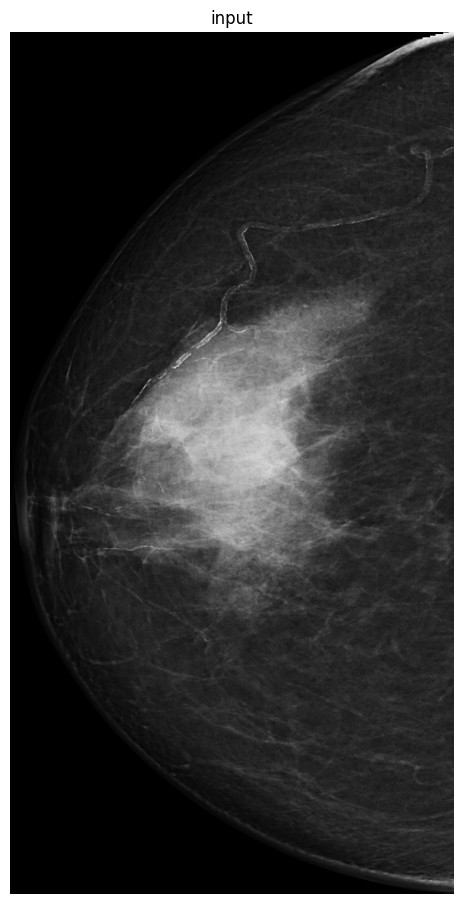

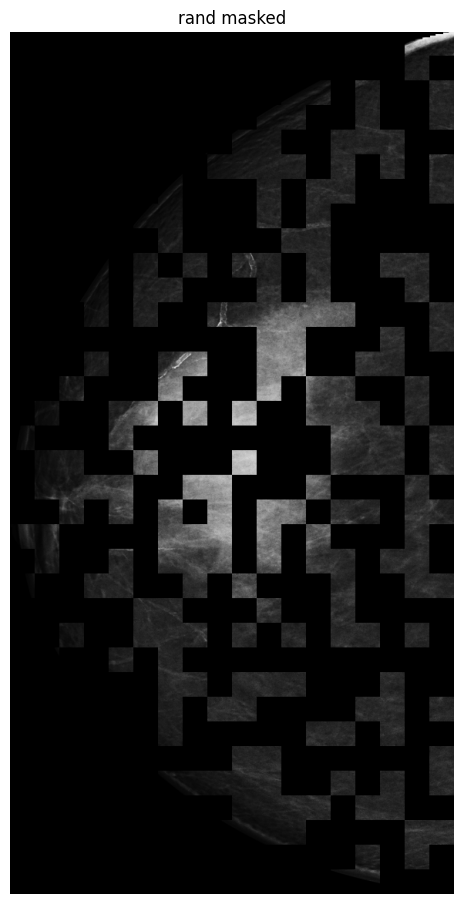

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


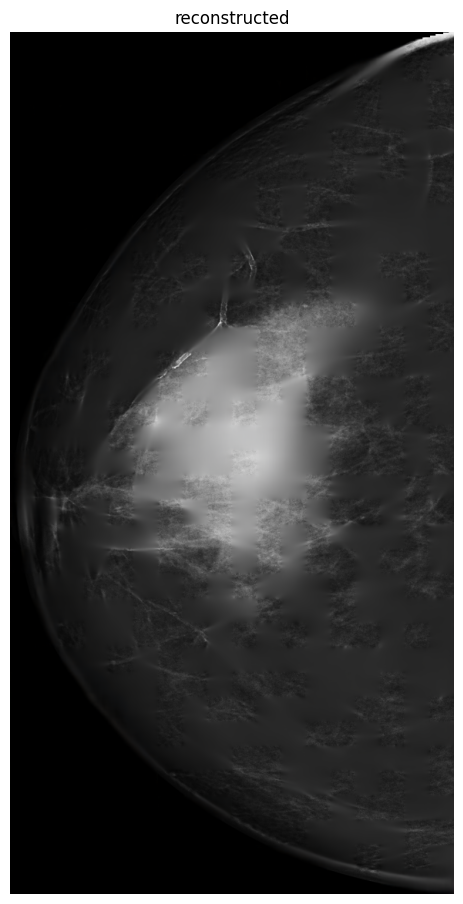

: 

In [28]:
# use a random mask (don't specify the mask)
show(spark, '/home/castrechini/projects/bac_project/dataset/processed_hbb/exams_with_vascular_calcs/4700119900cr.png', active_b1ff=None)